In [57]:

import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

import pandas as pd
import numpy as np

### Generate synthetic data

In [60]:
X_simple, y_simple = make_classification(
    n_samples=425,
    n_features=2,          
    n_informative=2,
    n_redundant=0,#?
    n_clusters_per_class=1,
    class_sep=1.5,         
    flip_y=0.06,
    random_state=42
)
X_simple[:5]

array([[ 1.51509604, -1.71297726],
       [ 1.90747976,  0.32405598],
       [ 2.25828253, -0.18708941],
       [ 1.9217387 , -2.08563405],
       [ 0.74547979, -0.76179868]])

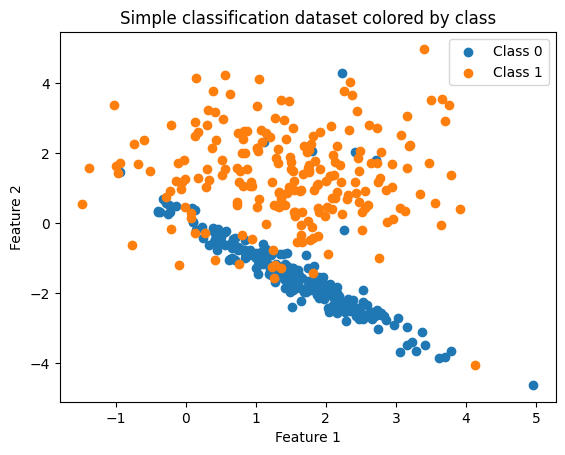

In [65]:
plt.figure()

for cls in (0,1):
    plt.scatter(
        X_simple[y_simple == cls, 0],
        X_simple[y_simple == cls, 1],
        label=f"Class {cls}"
    )
plt.title("Simple classification dataset colored by class")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

### Split data into train and test sets

In [66]:
X_train_simple, X_test_simple, y_train_simple, y_test_simple =  train_test_split(
    X_simple,
    y_simple,
    stratify=y_simple,
    random_state=2026,
)


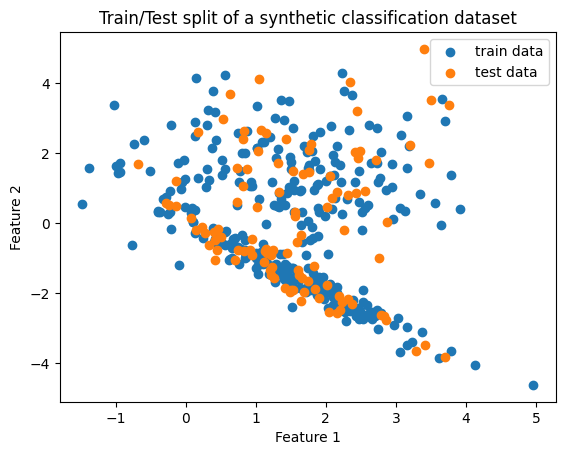

In [68]:
plt.figure()

for t, d in {'train': X_train_simple, 'test': X_test_simple}.items():
    plt.scatter(
        d[:, 0],
        d[:, 1],
        label=f"{t} data"
    )
plt.title("Train/Test split of a synthetic classification dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

### Check classes balance

In [70]:
pd.Series(y_simple).value_counts()

0    213
1    212
Name: count, dtype: int64

### Create and train the model

In [71]:
logreg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.5, max_iter=2000)),
    ]
)

logreg.fit(X_train_simple, y_train_simple)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(C=0.5, max_iter=2000))])

### Make predictions and evaluate the model

In [72]:
pred = logreg.predict(X_test_simple)
print(f"accuracy: {accuracy_score(y_test_simple, pred)}\nprecision: {precision_score(y_test_simple, pred, zero_division=0)}\nrecall: {recall_score(y_test_simple, pred, zero_division=0)}\nf1: {f1_score(y_test_simple, pred, zero_division=0)}")

accuracy: 0.8598130841121495
precision: 0.88
recall: 0.8301886792452831
f1: 0.8543689320388349
